In [40]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from utils import load_multi_traj_data
from model import DeepONet
import os
from matplotlib.patches import Ellipse
from tqdm import tqdm

In [41]:
def visualize_ellipsoid(gt_traj, test_traj, Q=None, c=1.0):
	# Perform a PCA on the reshaped data, data is of size (num_traj, traj_length, traj_dim), we can lump all trajectory together into (traj_length, traj_dim)
	reshaped_data = gt_traj.reshape(-1, gt_traj.shape[-1])
	if test_traj is not None:
		pred_traj = test_traj.reshape(-1, test_traj.shape[-1]).detach().cpu().numpy()
 
	print(reshaped_data.shape)
	pca = PCA(n_components=2)
	pca_traj_1 = pca.fit_transform(reshaped_data)
	if test_traj is not None:
		pca_traj_pred = pca.fit_transform(pred_traj)
	U = pca.components_

	if Q is None:
		# If no Q is provided, use the covariance
		Q = np.eye(U.shape[-1])
		c = c ** 2
		
	Q_inv = np.linalg.inv(Q)
	A = np.linalg.inv(U @ Q_inv @ U.T)

	# ----------------------------
	# Extract ellipse parameters from A:
	# The ellipse in PCA space is given by y^T A y = c.
	# Its semi-axis lengths are given by sqrt(c / eigenvalue).
	# The eigenvectors determine the orientation.
	# ----------------------------
	eigvals, eigvecs = np.linalg.eigh(A)
	print(eigvals)
	# Sort eigenvalues and eigenvectors in descending order.
	order = np.argsort(eigvals)[::-1]
	eigvals = eigvals[order]
	eigvecs = eigvecs[:, order]

	# Compute semi-axis lengths (for y^T A y = c)
	# print(eigvals)
	axis_length1 = np.sqrt(c / eigvals[0])
	axis_length2 = np.sqrt(c / eigvals[1])

	# Compute the rotation angle (in degrees) of the ellipse.
	angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

	# ----------------------------
	# Plot the projected ellipsoid in the 2D PCA space.
	# ----------------------------
	fig, ax = plt.subplots(figsize=(10, 10))

	# For a centered ellipsoid, the projected center is U*(x0 - x0)=0.
	ellipse_patch = Ellipse(xy=(0, 0),
							width=2 * axis_length1,   # full axis length in the first direction
							height=2 * axis_length2,  # full axis length in the second direction
							angle=angle,
							edgecolor='red', facecolor='none', lw=2
							)
	ax.add_patch(ellipse_patch)

	# Optionally, plot the PCA-transformed trajectory data for context.
	ax.scatter(pca_traj_1[:, 0], pca_traj_1[:, 1], s=2, alpha=0.3, label="PCA GT")
	if test_traj is not None:
		ax.scatter(pca_traj_pred[:, 0], pca_traj_pred[:, 1], s=2, alpha=0.3, label="PCA Pred")
	ax.set_xlim(-25, 25)
	ax.set_ylim(-25, 25)

	ax.set_xlabel('Component 1')
	ax.set_ylabel('Component 2')
	ax.legend()
	plt.axis('equal')

In [42]:
def rollout_on_test(eval_model, data_x, trunk_scale, test_traj, device):
	eval_model.eval()
	trunk_input = torch.tensor(data_x, dtype=torch.float32).to(device) * trunk_scale
 	# make trunk input 512 by 1, now it's 512
	trunk_input = trunk_input.view(512, 1)

	# print("trunk_input shape:", trunk_input.shape)
	test_traj = torch.tensor(test_traj, dtype=torch.float32).to(device)
	pred_traj = torch.zeros_like(test_traj).to(device)
	pred_traj[:, 0, :] = test_traj[:, 0, :].to(device)
 
	dt = 0.2
	# Q = eval_model.V._construct_Q().to(device)
	V_hist = torch.zeros(test_traj.shape[1]).to(device)
	
	for t in tqdm(range(test_traj.shape[1]-1)):
	# for t in tqdm(range(150)):
		with torch.no_grad():
		# Forward pass through the model
			input_t = (pred_traj[:, t, :], trunk_input)
			pred_traj[:, t+1, :] = eval_model(input_t)
   
			w_in = pred_traj[:, t, :]
			w_out = pred_traj[:, t+1, :]
			# w_diff = w_in - eval_model.V.x_0

			# dVdw = 2 * (w_diff @ Q)
			# # cond = (dVdw * w_out).sum(dim=1) - (dVdw * w_in).sum(dim=1) + dt * (eval_model.V(w_in) - eval_model.c ** 2)
			# A = dVdw
			# bx = eval_model.V(w_in)-(1/dt) * torch.einsum('bi,bi->b',dVdw, w_in) - eval_model.c**2
			# cond = torch.einsum('bi,bi->b',A,w_out) + bx
			# # print((dVdw ** 2).sum(dim=1))
   
			# if cond > 0:
			# 	print(f"Condition violated at timestep {t}: {cond.item()}")
			# # print(cond)
			V_hist[t] = eval_model.V(w_in)
			V_in = eval_model.V(w_in)
			V_out = eval_model.V(w_out)
			if V_in > eval_model.c ** 2:
				cond = V_out - V_in
				if cond > 0:
					print(f"Condition violated at timestep {t} OUTSIDE: {cond.item()}")
			else:
				cond = V_out - eval_model.c ** 2
				if cond > 0:
					print(f"Condition violated at timestep {t} INSIDE: {cond.item()}")

	# plot the V_hist against time
	plt.plot(V_hist.cpu().numpy())

	# plot c as a single line
	plt.plot(eval_model.c.detach().cpu().numpy() ** 2, label='c')
	plt.xlabel("Time step")
	plt.ylabel("V")
	plt.yscale("log")
	plt.title("V over time")
	plt.show()

	return pred_traj

Using device: cuda
Auto-detected flattened size for FC layer: 512
--- Initialized Branch Net Structure ---
Branch(
  (activation): ReLU()
  (conv_net): Sequential()
  (fc_net): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
)

--- Initialized Trunk Net Structure ---
Trunk(
  (activation): ReLU()
  (net): Sequential(
    (0): Linear(in_features=1, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
  )
)
----------------------------------------
-- Discrete Projection is ON --
Projection layer included
V_elliptical initialized with a DIAGONAL Q.
[[4.984743   0.         0.         ... 0.         0.         0.        ]
 [0.         4.3270135  0.         ... 0.         0.     

  2%|▏         | 217/9999 [00:00<00:04, 2168.99it/s]

Condition violated at timestep 0 OUTSIDE: 0.0078125
Condition violated at timestep 3 OUTSIDE: 0.0078125
Condition violated at timestep 7 OUTSIDE: 0.0078125
Condition violated at timestep 8 OUTSIDE: 0.0078125
Condition violated at timestep 10 OUTSIDE: 0.0078125
Condition violated at timestep 18 OUTSIDE: 0.0078125
Condition violated at timestep 19 OUTSIDE: 0.0078125
Condition violated at timestep 21 OUTSIDE: 0.015625
Condition violated at timestep 30 OUTSIDE: 0.015625
Condition violated at timestep 31 OUTSIDE: 0.015625
Condition violated at timestep 32 OUTSIDE: 0.015625
Condition violated at timestep 33 OUTSIDE: 0.0078125
Condition violated at timestep 36 OUTSIDE: 0.015625
Condition violated at timestep 39 OUTSIDE: 0.015625
Condition violated at timestep 45 OUTSIDE: 0.0078125
Condition violated at timestep 46 OUTSIDE: 0.0078125
Condition violated at timestep 48 OUTSIDE: 0.0078125
Condition violated at timestep 51 OUTSIDE: 0.0078125
Condition violated at timestep 53 OUTSIDE: 0.0078125
Con

  4%|▍         | 435/9999 [00:00<00:04, 2173.78it/s]

Condition violated at timestep 318 OUTSIDE: 0.0078125
Condition violated at timestep 322 OUTSIDE: 0.0078125
Condition violated at timestep 326 OUTSIDE: 0.0078125
Condition violated at timestep 328 OUTSIDE: 0.0078125
Condition violated at timestep 329 OUTSIDE: 0.0078125
Condition violated at timestep 331 OUTSIDE: 0.0078125
Condition violated at timestep 334 OUTSIDE: 0.0078125
Condition violated at timestep 337 OUTSIDE: 0.015625
Condition violated at timestep 339 OUTSIDE: 0.015625
Condition violated at timestep 345 OUTSIDE: 0.015625
Condition violated at timestep 346 OUTSIDE: 0.0078125
Condition violated at timestep 347 OUTSIDE: 0.0078125
Condition violated at timestep 353 OUTSIDE: 0.0078125
Condition violated at timestep 354 OUTSIDE: 0.0078125
Condition violated at timestep 357 OUTSIDE: 0.015625
Condition violated at timestep 360 OUTSIDE: 0.015625
Condition violated at timestep 367 OUTSIDE: 0.0078125
Condition violated at timestep 368 OUTSIDE: 0.0078125
Condition violated at timestep 37

...

Condition violated at timestep 9275 OUTSIDE: 0.0078125
Condition violated at timestep 9278 OUTSIDE: 0.0078125
Condition violated at timestep 9280 OUTSIDE: 0.0078125
Condition violated at timestep 9283 OUTSIDE: 0.015625
Condition violated at timestep 9287 OUTSIDE: 0.0078125
Condition violated at timestep 9290 OUTSIDE: 0.0078125
Condition violated at timestep 9291 OUTSIDE: 0.0078125
Condition violated at timestep 9293 OUTSIDE: 0.0078125
Condition violated at timestep 9295 OUTSIDE: 0.0078125
Condition violated at timestep 9296 OUTSIDE: 0.0078125
Condition violated at timestep 9301 OUTSIDE: 0.0078125
Condition violated at timestep 9305 OUTSIDE: 0.015625
Condition violated at timestep 9309 OUTSIDE: 0.0078125
Condition violated at timestep 9311 OUTSIDE: 0.0078125
Condition violated at timestep 9313 OUTSIDE: 0.0078125
Condition violated at timestep 9316 OUTSIDE: 0.0078125
Condition violated at timestep 9320 OUTSIDE: 0.015625
Condition violated at timestep 9323 OUTSIDE: 0.015625
Condition viol

 97%|█████████▋| 9654/9999 [00:04<00:00, 2187.34it/s]

Condition violated at timestep 9602 OUTSIDE: 0.0078125
Condition violated at timestep 9605 OUTSIDE: 0.0078125
Condition violated at timestep 9610 OUTSIDE: 0.015625
Condition violated at timestep 9615 OUTSIDE: 0.0078125
Condition violated at timestep 9617 OUTSIDE: 0.0078125
Condition violated at timestep 9622 OUTSIDE: 0.0078125
Condition violated at timestep 9623 OUTSIDE: 0.0078125
Condition violated at timestep 9631 OUTSIDE: 0.015625
Condition violated at timestep 9636 OUTSIDE: 0.0078125
Condition violated at timestep 9638 OUTSIDE: 0.0078125
Condition violated at timestep 9640 OUTSIDE: 0.015625
Condition violated at timestep 9643 OUTSIDE: 0.0078125
Condition violated at timestep 9648 OUTSIDE: 0.0078125
Condition violated at timestep 9650 OUTSIDE: 0.015625
Condition violated at timestep 9652 OUTSIDE: 0.0078125
Condition violated at timestep 9656 OUTSIDE: 0.0078125
Condition violated at timestep 9657 OUTSIDE: 0.0078125
Condition violated at timestep 9659 OUTSIDE: 0.0078125
Condition viol

100%|██████████| 9999/9999 [00:04<00:00, 2186.12it/s]

Condition violated at timestep 9719 OUTSIDE: 0.0078125
Condition violated at timestep 9720 OUTSIDE: 0.0078125
Condition violated at timestep 9722 OUTSIDE: 0.015625
Condition violated at timestep 9728 OUTSIDE: 0.015625
Condition violated at timestep 9730 OUTSIDE: 0.0078125
Condition violated at timestep 9734 OUTSIDE: 0.0078125
Condition violated at timestep 9738 OUTSIDE: 0.015625
Condition violated at timestep 9741 OUTSIDE: 0.015625
Condition violated at timestep 9743 OUTSIDE: 0.0078125
Condition violated at timestep 9744 OUTSIDE: 0.0078125
Condition violated at timestep 9749 OUTSIDE: 0.0078125
Condition violated at timestep 9755 OUTSIDE: 0.0078125
Condition violated at timestep 9760 OUTSIDE: 0.0078125
Condition violated at timestep 9763 OUTSIDE: 0.015625
Condition violated at timestep 9770 OUTSIDE: 0.0234375
Condition violated at timestep 9771 OUTSIDE: 0.0078125
Condition violated at timestep 9777 OUTSIDE: 0.015625
Condition violated at timestep 9779 OUTSIDE: 0.0078125
Condition violat

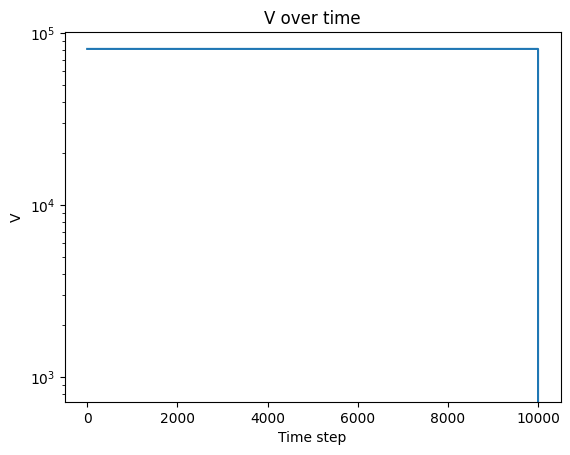

In [43]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model_path = 'Trained_Models/0819_01/E10000_TS0.05_branchConv0_trunkHidden3__proj_LamRegVol0.1_C030.0_diagQ_discrete_proj_True_smooth_False' + '/model_epoch_best.pt'
# model_params = np.load(model_path.replace('model_epoch_best.pt', 'model_params.npz'), allow_pickle=True)

# Step 1: Load the read-only .npz file
# loaded_data = np.load(model_path.replace('model_epoch_best.pt', 'model_params.npz'), allow_pickle=True)

# Step 2: Copy its contents into a new, editable dictionary 📋
model_params = {
    'm': 512,
    'n': 1,
    'epochs': 10000,
    'bsize': 2048,
    'lam_reg_vol': 0.1,
    'project': True,
    'tag': '',
    'c0': 30.0,
    'dt': 0.2,
    'trainable_c': False,
    'trunk_scale': 0.05,
    'diag_Q': True,
    'output_dim': 256,
    'branch_conv_channels': [],
    'branch_fc_dims': [256],
    'trunk_hidden_dims': [256, 256, 256],
    'discrete_proj': True,
}

# # Step 3: Now you can modify the new dictionary
# model_params['m'] = int(model_params['m']) 
# print(model_params)

eval_model = DeepONet(model_params).to(device)
# load the state dictionary from model_path to the eval_model
eval_model.load_state_dict(torch.load(model_path, map_location=device))

Q = eval_model.V._construct_Q().detach().cpu().numpy()
print(Q)
# Q = np.eye(512)
c = eval_model.c.detach().cpu().numpy() ** 2
eval_model.eval()

data_path = 'Data/KS_data_test_l100.53_grid512_M1_T2000.0_dt0.005_dt_sample0.2_amp20.0.npz/data.npz'

# --- 2. Load Data ---
print(f"Loading data from {data_path}...")
data = np.load(data_path, allow_pickle=True)

test_traj = data['u_batch']
pred_traj = rollout_on_test(eval_model, data['x'], model_params['trunk_scale'], test_traj, device)

(10000, 512)
[0.8430605 0.9071324]


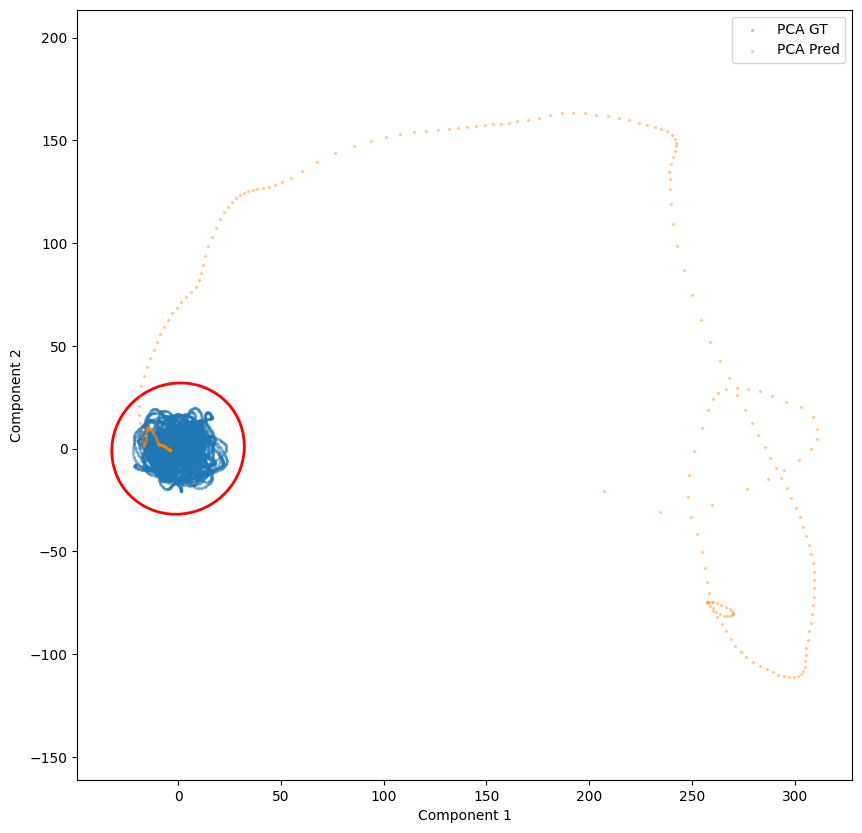

In [44]:
visualize_ellipsoid(test_traj, pred_traj, Q, c)
# visualize_ellipsoid(test_traj, None, Q, c)